# RQ3 — Challenges and Support (Q21–Q22)

**Analysis to Address RQ3**: Q21–Q22 — main challenges to guarantee data reliability and frequency of support from other teams.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
print(f"N={len(df)}")


N=56


## Canonical options and helper functions

In [2]:
Q21_OPTIONS = {
    "q21_inconsistency": [
        "Inconsistência entre diferentes fontes de dados",
        "Inconsistency between different data sources",
    ],
    "q21_incompleteness": ["Dados incompletos ou ausentes", "Incomplete or missing data"],
    "q21_no_standard": [
        "Falta de padronização nos formatos de dados",
        "Lack of standardization in data formats",
    ],
    "q21_outdated": ["Dados desatualizados ou não confiáveis", "Outdated or unreliable data"],
    "q21_collection_errors": [
        "Erros introduzidos durante a coleta e processamento",
        "Errors introduced during collection and processing",
    ],
    "q21_traceability": [
        "Dificuldade na rastreabilidade e versionamento dos dados",
        "Difficulty in data traceability and versioning",
    ],
    "q21_no_tools": [
        "Falta de ferramentas adequadas para validação da qualidade dos dados",
        "Lack of adequate tools for validating data quality",
    ],
}
Q21_LABELS = {
    "q21_inconsistency": "Inconsistency across sources",
    "q21_incompleteness": "Incomplete/missing data",
    "q21_no_standard": "Lack of format standardization",
    "q21_outdated": "Outdated/unreliable data",
    "q21_collection_errors": "Errors in collection and processing",
    "q21_traceability": "Difficulty in traceability/versioning",
    "q21_no_tools": "Lack of validation tools",
}


Q21: n=56, average options marked = 3.39
Q21 residuals:
  P13: 'Estrutura dos dados, Natureza dos dados'


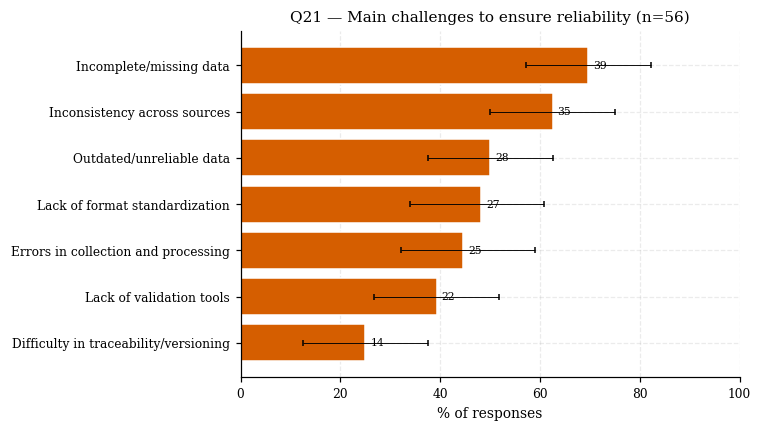

In [3]:
rng = np.random.default_rng(42)

def _boot_ci(values, threshold=4, n_bootstrap=1000, ci_level=0.95):
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return float("nan"), float("nan")
    alpha = 1 - ci_level
    boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
    boot_props = np.mean(values[boot_indices] >= threshold, axis=1)
    return np.percentile(boot_props, 100 * alpha / 2), np.percentile(boot_props, 100 * (1 - alpha / 2))

def parse_checkboxes(series, options):
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, raw in options.items():
        labels = [raw] if isinstance(raw, str) else list(raw)
        present = pd.Series(False, index=series.index)
        for lab in labels:
            present = present | series.fillna("").str.contains(lab, regex=False)
            residual = residual.fillna("").str.replace(lab, "", regex=False)
        binary[key] = present
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual

def proportions_with_ci(binary, labels, n_total):
    rows = []
    for key in binary.columns:
        vals = binary[key].astype(int).values
        lo, hi = _boot_ci(vals, threshold=1)
        rows.append({
            "key": key, "label": labels[key],
            "n": int(binary[key].sum()),
            "pct": binary[key].mean() * 100,
            "ci_lo": lo * 100, "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

def horizontal_bar(p, title, color, ax):
    p_sorted = p.sort_values("pct")
    y = np.arange(len(p_sorted))
    ax.barh(y, p_sorted["pct"], color=color, edgecolor="white")
    err_lo = np.clip(p_sorted["pct"] - p_sorted["ci_lo"], 0, None)
    err_hi = np.clip(p_sorted["ci_hi"] - p_sorted["pct"], 0, None)
    ax.errorbar(p_sorted["pct"], y, xerr=[err_lo, err_hi],
                fmt="none", ecolor="black", elinewidth=0.6, capsize=2)
    ax.set_yticks(y)
    ax.set_yticklabels(p_sorted["label"])
    ax.set_xlabel("% of responses")
    ax.set_xlim(0, 100)
    ax.set_title(title)
    for i, (pct, n) in enumerate(zip(p_sorted["pct"], p_sorted["n"])):
        ax.text(pct + 1, i, f"{int(n)}", va="center", fontsize=7)


q21_bin, q21_res = parse_checkboxes(df["challenges_open"], Q21_OPTIONS)
n_q21 = df["challenges_open"].notna().sum()
print(f"Q21: n={n_q21}, average options marked = {q21_bin.sum(axis=1).mean():.2f}")

nonempty = q21_res[q21_res.str.len() > 0]
if len(nonempty):
    print("Q21 residuals:")
    for idx, txt in nonempty.items():
        print(f"  P{idx:02d}: {txt!r}")

p21 = proportions_with_ci(q21_bin, Q21_LABELS, n_q21)
fig, ax = plt.subplots(1, 1, figsize=(7.0, 4.0))
horizontal_bar(p21, f"Q21 — Main challenges to ensure reliability (n={n_q21})", U.PALETTE_WONG[6], ax)
fig.tight_layout()
U.save_fig(fig, "challenges_q21")
plt.show()


## Q21 — Parsing and Proportions

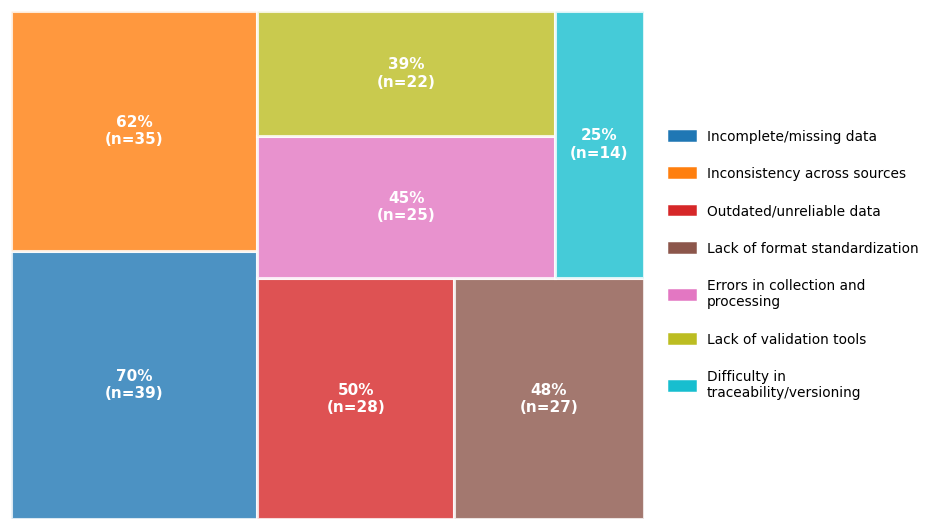

In [4]:
import squarify
import textwrap

rows = []
for key in q21_bin.columns:
    n = int(q21_bin[key].sum())
    pct = q21_bin[key].mean() * 100
    rows.append({
        "label": Q21_LABELS[key],
        "n": n,
        "pct": pct
    })

p21 = (
    pd.DataFrame(rows)
    .sort_values("pct", ascending=False)
    .reset_index(drop=True)
)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

fig, ax = plt.subplots(figsize=(10, 6))

sizes = p21["pct"].values
colors = plt.cm.tab10(np.linspace(0, 1, len(sizes)))

inner_labels = [
    f"{pct:.0f}%\n(n={n})"
    for pct, n in zip(p21["pct"], p21["n"])
]

squarify.plot(
    sizes=sizes,
    label=inner_labels,
    color=colors,
    alpha=0.8,
    edgecolor="white",
    linewidth=2,
    ax=ax,
    text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'white'}
)

import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color=colors[i], label=textwrap.fill(p21["label"][i], width=30)) 
    for i in range(len(p21))
]

ax.legend(
    handles=legend_handles,
    loc="center left",           # Ancora o centro-esquerdo da caixa da legenda
    bbox_to_anchor=(1.02, 0.5),  # Posiciona logo após o fim do gráfico (x=1.02) e no meio da altura (y=0.5)
    ncol=1,                      # Empilha uma sobre a outra
    frameon=False,
    fontsize=9,
    labelspacing=1.7,            # Espaço vertical entre as legendas
    handletextpad=0.8            # Espaço entre o quadrado colorido e o texto
)

plt.subplots_adjust(right=0.70) 

ax.axis("off")

U.save_fig(fig, "challenges_q21_treemap_right_legend")
plt.show()

## Q22 — Support Frequency from Other Teams

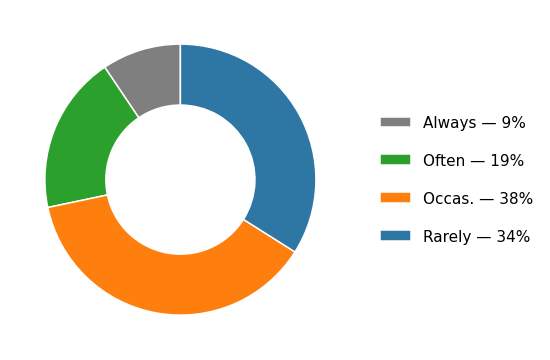

In [7]:
labels_rev = ["Always", "Often", "Occas.", "Rarely"]

# 2. Preparação dos dados (Invertendo para a legenda seguir a ordem Always -> Rarely)
counts_rev = df["support_freq"].value_counts(dropna=False).reindex([4, 3, 2, 1], fill_value=0)
pct_rev = counts_rev / counts_rev.sum() * 100

colors_rev = ["#7F7F7F", "#2CA02C", "#FF7F0E", "#2E77A5"]

fig, ax = plt.subplots(figsize=(7, 4))

wedges, _ = ax.pie(
    pct_rev.values,
    labels=None,
    startangle=90,
    colors=colors_rev,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white"
    }
)

legend_labels = [f"{labels_rev[i]} — {pct_rev.values[i]:.0f}%" for i in range(len(labels_rev))]

ax.legend(
    wedges,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5), 
    ncol=1,
    frameon=False,
    fontsize=10,
    labelspacing=1.5 
)

fig.subplots_adjust(right=0.65) 

U.save_fig(fig, "frequency_q22_donut")
plt.show()